In [163]:
#librerias
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import sosfiltfilt,  iirdesign, sosfreqz,  find_peaks, lfilter
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.io as sio
DB_PATH = "dat" #nombre de la carpeta donde esta la info

In [164]:
def leer_archivo(record_name="sz01", mostrar= True):

    # Leer el registro ECG 
    ruta = os.path.join(DB_PATH, record_name)
    record = wfdb.rdrecord(ruta)
    ecg = record.p_signal[:, 0]
    fs = record.fs

    #leer latidos
    ann = wfdb.rdann(ruta, 'ari')
    r_peaks = ann.sample
    t = np.arange(len(ecg)) / fs

    record = wfdb.rdrecord(os.path.join(DB_PATH, record_name))
    ecg = record.p_signal[:, 0]   # ECG monoderivación
    fs = record.fs                # frecuencia de muestreo (200 Hz)

    # Vector de tiempo
    t = np.arange(len(ecg)) / fs

    ## obtengo tiempos del episodio
    seizure_times = load_seizure_times(os.path.join(DB_PATH, "times.seize"), record_name)
    print("Seizures encontradas:", seizure_times)
    if mostrar:

        #ECG c/ latiodos
        plt.figure(figsize=(12, 4))
        plt.plot(t, ecg, label="ECG", linewidth=1)
        plt.plot(r_peaks / fs, ecg[r_peaks],'ro',markersize=4, label="R-peaks (.ari)")
        plt.xlabel("Tiempo [s]")
        plt.xlim(seizure_times[0])
        plt.ylabel("Amplitud[mV]")
        plt.title("ECG con latidos detectados (archivo .ari)")
        plt.legend()
        plt.grid(True)
        plt.show()
        
         # ECG
        plt.figure(figsize=(15, 4))
        plt.plot(t, ecg, color="blue", linewidth=0.8, label="ECG")

        # Marcar cada seizure
        for i, (start, end) in enumerate(seizure_times):
            plt.axvspan(start,end, color="red", alpha=0.3, label="Seizure" if i == 0 else None)

        plt.xlabel("Tiempo (s)")
        plt.ylabel("Amplitud ECG")
        plt.title(f"ECG completo – {record_name} (seizures marcadas)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        for i, (start, end) in enumerate(seizure_times):

            mask = (t >= start - int(start / 200)) & (t <= end + int(end / 200))
            
            plt.figure(figsize=(12, 4))
            plt.plot(t[mask], ecg[mask])
            plt.axvspan(start, end, color="red", alpha=0.3, label="Seizure" if i == 0 else None)
            plt.xlabel("Tiempo (s)")
            plt.ylabel("Amplitud ECG")
            plt.title(f"{record_name} – Seizure {i+1}")
            plt.grid(True)
            plt.show()
    r_peaks= r_peaks / fs # latidos en tiempo
    return ecg, t, fs, seizure_times, r_peaks
def hms_to_seconds(hms): # de hh:mm:ss a entero
    h, m, s = hms.split(':')
    return int(h) * 3600 + int(m) * 60 + float(s)

def load_seizure_times(filepath, record_name):
    seizures = []
    with open(filepath, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 3 and parts[0] == record_name:
                start = hms_to_seconds(parts[1])
                end = hms_to_seconds(parts[2])
                seizures.append((start, end))
    return seizures


In [165]:
def ecg_filter_butter(ecg, t,fs=200, mostrar= True):

    # ---------- Parámetros de diseño ----------
    wp_band = np.array([1, 35])      # banda pasante [Hz]
    ws_band = np.array([0.1, 40])    # banda de rechazo [Hz]

    # Frecuencias límite (escalares, para gráficos)
    fp1, fp2 = wp_band
    fs1, fs2 = ws_band

    # Atenuaciones (forward + backward → mitad por etapa)
    alpha_p = 0.5    # ripple pasante [dB]
    alpha_s = 20     # atenuación stopband [dB]

    # ---------- Diseño IIR Butterworth ----------
    sos_butt = iirdesign(wp=wp_band, ws=ws_band, gpass=alpha_p, gstop=alpha_s, ftype='butter', fs=fs, output='sos')

    # ---------- Respuesta en frecuencia ----------
    n_fft = 4096
    w, h = sosfreqz(sos_butt, worN=n_fft, fs=fs)
    mag_db = 20 * np.log10(np.maximum(np.abs(h), 1e-12))

    # ---------- Fase y retardo de grupo ----------
    fase = np.unwrap(np.angle(h))
    w_rad = w / (fs / 2) * np.pi
    gd = -np.diff(fase) / np.diff(w_rad)

    # =================================================
    #                   GRÁFICOS
    # =================================================

    # ---------- Magnitud ----------
    plt.figure(figsize=(9, 4))
    plt.plot(w, mag_db, label='Filtro digital', color='C0')

    # Banda pasante
    plt.fill_between(
        [fp1, fp2],
        -alpha_p, 5,
        color='lightgreen',
        alpha=0.5,
        label='Banda pasante'
    )

    # Banda de rechazo baja
    plt.fill_between(
        [0, fs1],
        -100, -alpha_s,
        color='lightgreen',
        alpha=0.5
    )

    # Banda de rechazo alta
    plt.fill_between(
        [fs2, fs / 2],
        -100, -alpha_s,
        color='lightgray',
        alpha=0.5,
        label='Banda de rechazo'
    )

    # Líneas de especificación (ESCALARES)
    plt.axvline(fp1, linestyle='--', color='k')
    plt.axvline(fp2, linestyle='--', color='k')
    plt.axvline(fs1, linestyle='--', color='k')
    plt.axvline(fs2, linestyle='--', color='k')
    plt.axhline(-alpha_s, linestyle='--', color='k')

    plt.title('Filtro IIR Butterworth – ECG (Pasa Banda)')
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('|H(jω)| [dB]')
    plt.xlim([0, fs / 2])
    plt.ylim([-100, 10])
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------- Fase ----------
    plt.figure(figsize=(9, 4))
    plt.plot(w, fase)
    plt.title('Filtro IIR Butterworth – Fase')
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('Fase [rad]')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ---------- Retardo de grupo ----------
    plt.figure(figsize=(9, 4))
    plt.plot(w[1:], gd)
    plt.title('Filtro IIR Butterworth – Retardo de Grupo')
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('τg [muestras]')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ---------- Filtrado ----------
    y = sosfiltfilt(sos_butt, ecg)
    
    if mostrar:
        plt.figure(figsize=(12, 6))
        # ECG crudo
        plt.subplot(2, 1, 1)
        plt.plot(t, ecg, color='tab:gray')
        plt.xlim(850)
        plt.title('ECG crudo')
        plt.ylabel('Amplitud [u.a.]')
        plt.grid(True)

        # ECG filtrado
        plt.subplot(2, 1, 2)
        plt.plot(t, y, color='tab:blue')
        plt.xlim(850)
        plt.title('ECG filtrado (IIR Butterworth pasa-banda)')
        plt.xlabel('Tiempo [s]')
        plt.ylabel('Amplitud [u.a.]')
        plt.grid(True)

        plt.tight_layout()
        plt.show()
    return y


# Explicacion / ayuda memoria pan tomikins
![alt text][def]

[def]: image.png

## algoritmo PAN-TOMPINKS
https://www.youtube.com/watch?v=fZWM_a89ICk
1. Filtro pasabanda --> butter --> el video que lo explica recomien 5-15hz de banda pasante --> establece que en esa frecuencia se encuentra la mayor parte de la energia util del ecg
2. Diferenciador --> mide los cambios en la pendiente (rate of change punto a punto) --> hallar el pico (r peak --> steepest point)
3. Non linear squaring --> toda la senal se convierte en positiva + suprime ruidos pequnos
4. Integrador con ventana movil --> senal suavizada
5. Umbral adaptativo --> utiliza 2, uno para el nivel de ruido y otro para el nivel de la senal

In [166]:
def detect_rpeaks(ecg, t, fs=200, win_ms=120, refractory_ms=200, mostrar= True):
    """
    Devuelve índices de picos R en la señal original.
    """
    # 1) Filtrado para resaltar QRS atenuar: bajas frec(deriva de línea base, respiración, onda P) y altas frec (ruido muscular/EMG).
    ecg_f = ecg_filter_butter(ecg, t)

    # 2) Realce tipo Pan-Tompkins: derivada + cuadrado + ventana móvil
    d = np.diff(ecg_f, prepend=ecg_f[0]) #derivda discreta
    y = d**2                            #energia de la pendiente
    win = max(1, int(round(win_ms * fs / 1000.0)))#ventana de muestras
    kernel = np.ones(win) / win
    # Convolución con misma longitud
    y_int = np.convolve(y, kernel, mode='same') #promedio movil

    # 3) Umbral adaptativo simple
    thr = 0.5 * np.median(y_int[y_int > 0])  # evita ceros
    prom = 0.5 * thr # Prominence mínima relativa


    # 4) Búsqueda de picos en y_int (no directamente en ecg)
    # refractory = 200 ms (para adulto típico). 
    distance = int(round(refractory_ms * fs / 1000.0))
    peaks, props = find_peaks(y_int, height=thr, prominence=prom, distance=distance)

    # 5) Refino posición del pico: mover al máximo local en ecg_f cerca del pico
    r_locs = []
    radius = max(1, int(round(0.08 * fs)))  # ±80 ms
    n = len(ecg_f)
    for p in peaks:
        i0 = max(0, p - radius)
        i1 = min(n, p + radius + 1)
        if i1 > i0:
            local = np.argmax(ecg_f[i0:i1]) + i0
            r_locs.append(local)
    r_locs = np.array(sorted(set(r_locs)))  # únicos y ordenados

    if mostrar:
        plt.figure(figsize=(12, 6))
        # Señal ECG filtrada
        plt.plot(t, ecg_f, label="ECG filtrado", color="black", linewidth=1)
        #Marcar picos R
        plt.plot(t[r_locs], ecg_f[r_locs], "ro", label="Picos R detectados")

        plt.xlabel("Tiempo [s]")
        plt.ylabel("Amplitud")
        plt.xlim (4080,4170)
        plt.title("Detección de picos R (Algoritmo de Pan–Tompkins)")
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

    return r_locs, ecg_f, y_int, thr


In [167]:
## Filtro adaptado ECG
def filtro_adp(ecg,fs=200):
    # Cargar patrón QRS
    mat_struct = sio.loadmat('./ecg.mat')
    patron = mat_struct['qrs_pattern1'].flatten()

    # Quitar componente DC (área nula)
    patron = patron - np.mean(patron)

    # Filtro adaptado (correlación FIR)
    ecg_filt = lfilter(b=patron, a=1, x=ecg)

    # Normalización
    ecg_filt_norm = np.abs(ecg_filt)
    ecg_filt_norm /= np.std(ecg_filt_norm)
    ecg_norm = ecg / np.std(ecg)

    # Detección de picos

    picos, _ = find_peaks(
        ecg_filt_norm,
        height=1,
        distance=300 #parametro electrofisologico
    )

    return picos, ecg_norm, ecg_filt_norm
def plot_ecg_y_latidos(ecg, fs=200, N=5000):
    """
    Grafica:
    - Arriba: salida del filtro adaptado con latidos detectados
    - Abajo: ECG original normalizado
    """

    picos, ecg_norm, ecg_filt_norm = filtro_adp(ecg, fs)

    t = np.arange(len(ecg)) / fs

    # Limitar a N muestras para claridad
    picos = picos[picos < N]

    plt.figure(figsize=(14, 6))

    # ---------- Señal filtrada ----------
    plt.subplot(2, 1, 1)
    plt.plot(t[:N], ecg_filt_norm[:N], label='Salida filtro adaptado')
    plt.plot(t[picos], ecg_filt_norm[picos],'ro', label='Latidos detectados')
    plt.title('Detección de QRS – Filtro Adaptado')
    plt.ylabel('Amplitud normalizada')
    plt.legend()
    plt.grid(True)

    # ---------- ECG original ----------
    plt.subplot(2, 1, 2)
    plt.plot(t[:N], ecg_norm[:N], color='black', label='ECG original')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud normalizada')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


In [168]:
## Matriz de confusion
def matriz_confusion_qrs(mis_qrs, qrs_det, fs=200, tolerancia_ms=200):
    """
    Calcula matriz de confusión para detecciones QRS usando solo NumPy y SciPy
    
    Parámetros:
    - mis_qrs: array con tiempos de tus detecciones (muestras)
    - qrs_det: array con tiempos de referencia (muestras)  
    - tolerancia_ms: tolerancia en milisegundos (default 150ms)
    - fs: frecuencia de muestreo (default 200 Hz)
    """
    
    # Convertir a arrays numpy
    mis_qrs = np.array(mis_qrs)
    qrs_det = np.array(qrs_det)
    
    # Convertir tolerancia a muestras
    tolerancia_muestras = tolerancia_ms * fs / 1000 # 1000--> convierto de milisegundo a s
    
    # Inicializar contadores
    TP = 0  # True Positives
    FP = 0  # False Positives
    FN = 0  # False Negatives
    
    # Arrays para marcar detecciones ya emparejadas
    mis_qrs_emparejados = np.zeros(len(mis_qrs), dtype=bool)
    qrs_det_emparejados = np.zeros(len(qrs_det), dtype=bool)
    
    # Encontrar True Positives (detecciones que coinciden dentro de la tolerancia)
    for i, det in enumerate(mis_qrs):
        diferencias = np.abs(qrs_det - det)
        min_diff_idx = np.argmin(diferencias)
        min_diff = diferencias[min_diff_idx]
        
        if min_diff <= tolerancia_muestras and not qrs_det_emparejados[min_diff_idx]:
            TP += 1
            mis_qrs_emparejados[i] = True
            qrs_det_emparejados[min_diff_idx] = True
    
    
    FP = np.sum(~mis_qrs_emparejados) # False Positives --> mis detecciones no emparejadas
    FN = np.sum(~qrs_det_emparejados) # False Negatives --> detecciones de referencia no emparejadas
    
    # Construir matriz de confusión
    matriz = np.array([
        [TP, FP],
        [FN, 0]  # TN generalmente no aplica en detección de eventos
    ])

    if print:
       print("Matriz de Confusión:")
    print(f"           Predicho")
    print(f"           Sí    No")
    print(f"Real Sí:  [{TP:2d}   {FN:2d}]")
    print(f"Real No:  [{FP:2d}    - ]")
    print(f"\nTP: {tp}, FP: {fp}, FN: {fn}")

    # Calcular métricas de performance
    if TP + FP > 0:
        precision = TP / (TP + FP)
    else:
       precision = 0

    if TP + FN > 0:
        recall = TP / (TP + FN)
    else:
        recall = 0

    if precision + recall > 0:
        f1_score = 2 * (precision * recall) / (precision + recall)
    else:
        f1_score = 0

    print(f"\n-------------Métricas---------------")
    print(f"Precisión: {precision:.3f}")
    print(f"Sensibilidad: {recall:.3f}")
    print(f"F1-score: {f1_score:.3f}")
    
    return matriz, TP, FP, FN

Seizures encontradas: [(4082.0, 4171.0)]


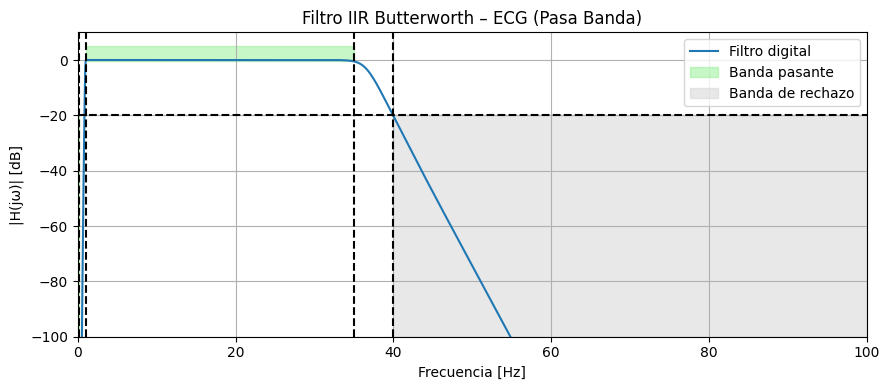

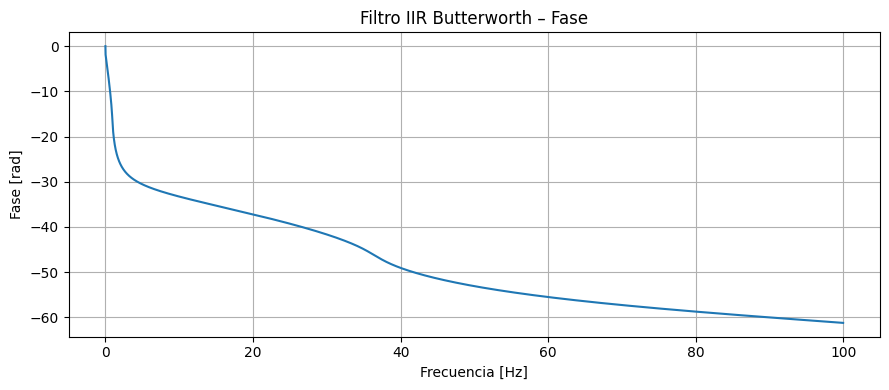

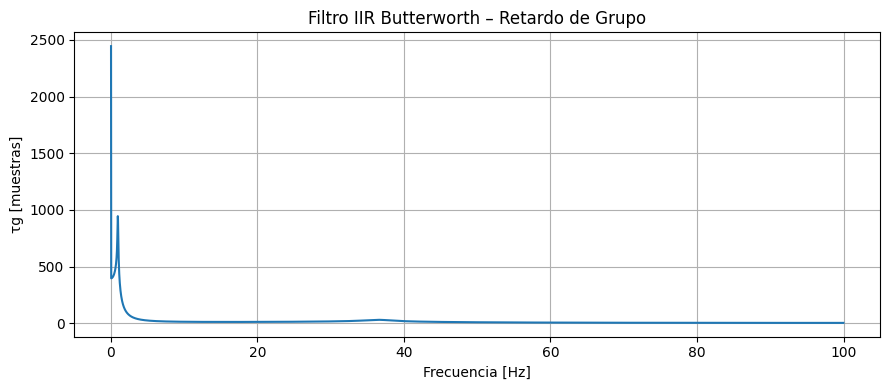

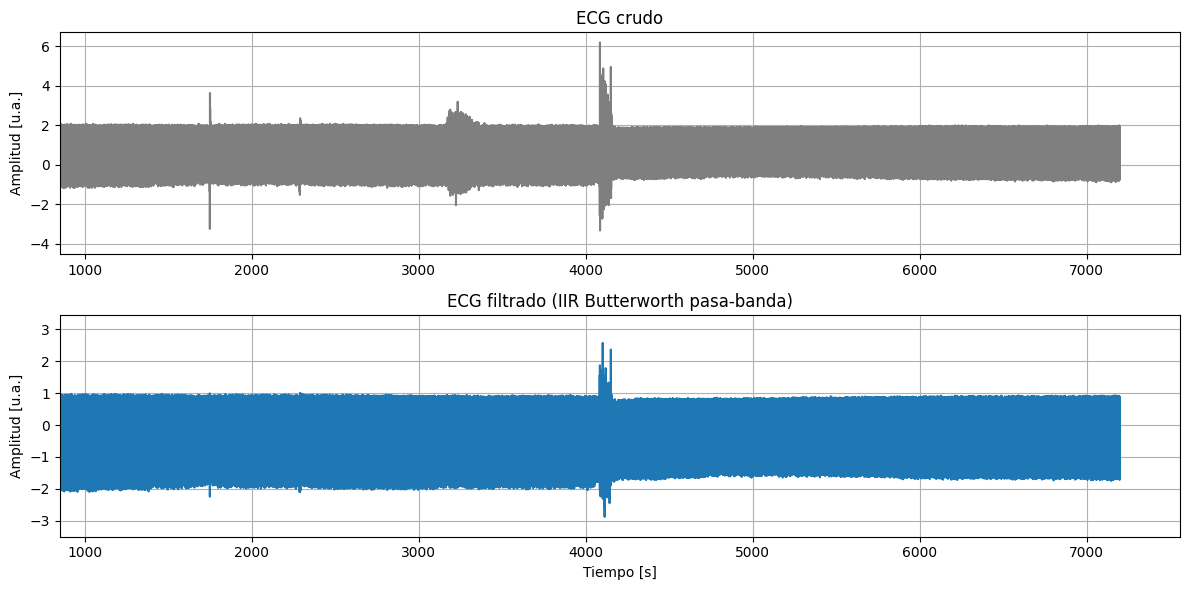

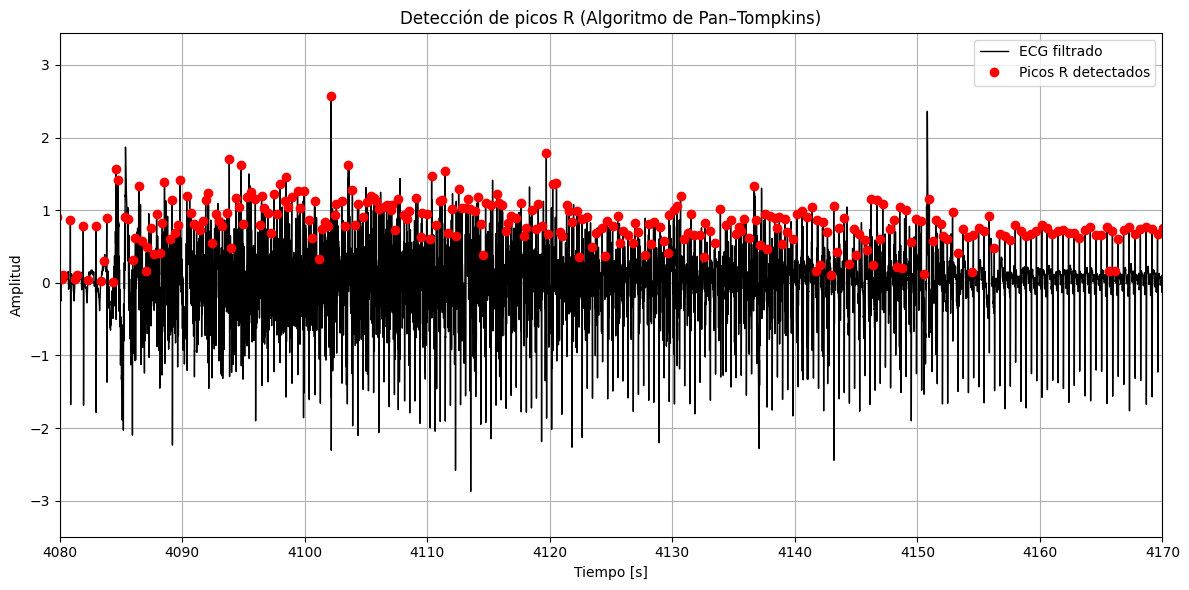

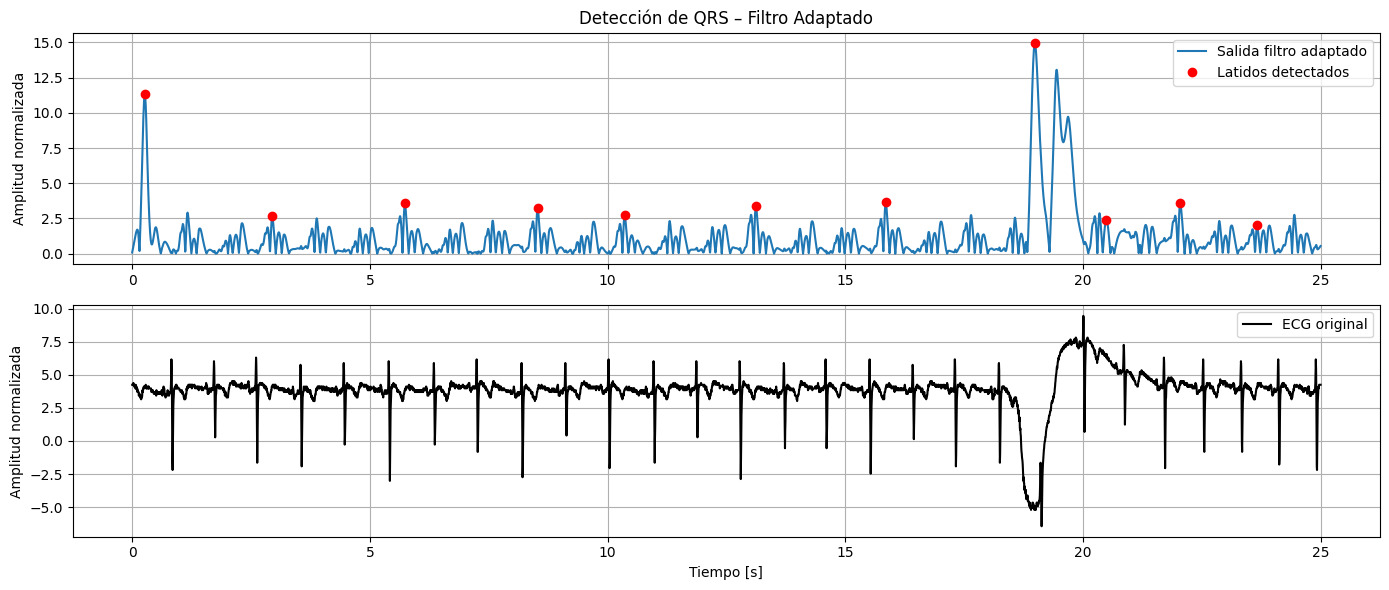

Matriz de Confusión:
           Predicho
           Sí    No
Real Sí:  [90   17864]
Real No:  [8802    - ]

TP: 90, FP: 8802, FN: 17864

-------------Métricas---------------
Precisión: 0.010
Sensibilidad: 0.005
F1-score: 0.007
Matriz de Confusión:
           Predicho
           Sí    No
Real Sí:  [16   3795]
Real No:  [8876    - ]

TP: 90, FP: 8802, FN: 17864

-------------Métricas---------------
Precisión: 0.002
Sensibilidad: 0.004
F1-score: 0.003


In [169]:
# implementacion
ecg, t, fs, seizure_times, r_peaks = leer_archivo("sz07", False)
r_locs, ecg_f, y_int, thr = detect_rpeaks (ecg,t, fs)
r_locs_mf,_,_=filtro_adp (ecg)
plot_ecg_y_latidos(ecg, fs=200)
matriz, tp, fp, fn = matriz_confusion_qrs(r_peaks, r_locs, fs)
matriz_mf, _,_,_=matriz_confusion_qrs(r_peaks, r_locs_mf, fs)